In [1]:
from notus import utils, ByteLevelTokenizer, eval, CompressionEngine, FileFormer, FileDataset
import torch

In [2]:
tokenizer = ByteLevelTokenizer()
configs = utils.load_config("../config/config.yml")
loss_fn = torch.nn.CrossEntropyLoss(ignore_index=1)

In [3]:
fileformer = FileFormer.load_from_checkpoint("/Users/daniilogorodnikov/model-epoch=02-step=110000.ckpt", loss_fn=loss_fn, config=configs, device="mps")

/Users/daniilogorodnikov/anaconda3/envs/notus/lib/python3.12/site-packages/lightning/pytorch/utilities/migration/utils.py:56: The loaded checkpoint was produced with Lightning v2.5.5, which is newer than your current Lightning version: v2.5.0.post0


In [4]:
from torch.utils.data import DataLoader
dataset = FileDataset(**configs['dataset'])
dataloader = DataLoader(dataset, batch_size=1,
                        shuffle=True, num_workers=configs['train']['num_workers']
                        )

Preparing files: 100%|██████████| 11/11 [00:00<00:00, 19.14it/s]


In [5]:
from tqdm import tqdm

In [6]:
hashs = []
emb = []
extention = []

In [7]:
for _, i in tqdm(enumerate(dataloader)):
    tokens, masked_tokens, pads, hash, extention_tokenize = i
    hashs.append(tokenizer.decode(hash.tolist()[0])[:64])
    extention.append(extention_tokenize.tolist()[0])
    with torch.no_grad():
        emb.append(fileformer.decoder.chunk_emb(tokens)[0].half().mean(dim=0).cpu().numpy())




178860it [00:47, 3773.45it/s]


In [8]:
import pandas as pd

In [9]:
df = pd.DataFrame({
    'hash': hashs,
    'emb': emb,  # emb как список тензоров (seqlen, 1024)
    'ext': extention
})

In [ ]:
df.head(1)

In [10]:
import pandas as pd
import torch
import numpy as np
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap  # pip install umap-learn
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
embeddings = []
for e in df['emb']:
    #mean_emb = e.mean(dim=0).cpu().numpy()  # (1024,)
    embeddings.append(e)
embeddings = np.array(embeddings)

In [12]:
pca = PCA(n_components=50)
embeddings_pca = pca.fit_transform(embeddings)

In [13]:
from umap.umap_ import UMAP

/Users/daniilogorodnikov/anaconda3/envs/notus/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [18]:
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
embeddings_2d = tsne.fit_transform(embeddings_pca)

In [14]:
reducer = UMAP(n_components=2, random_state=42)
embeddings_2d = reducer.fit_transform(embeddings_pca)

/Users/daniilogorodnikov/anaconda3/envs/notus/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


In [15]:
embeddings_2d

array([[13.394443 ,  1.6063203],
       [ 8.315838 ,  9.8858795],
       [12.052313 , -6.3397365],
       ...,
       [ 8.104308 , 10.576686 ],
       [11.830612 ,  8.7591505],
       [10.786816 , -8.622465 ]], shape=(178860, 2), dtype=float32)

In [19]:
ext_values = [x[0] for x in df['ext']]

Text(0, 0.5, 'Component 2')

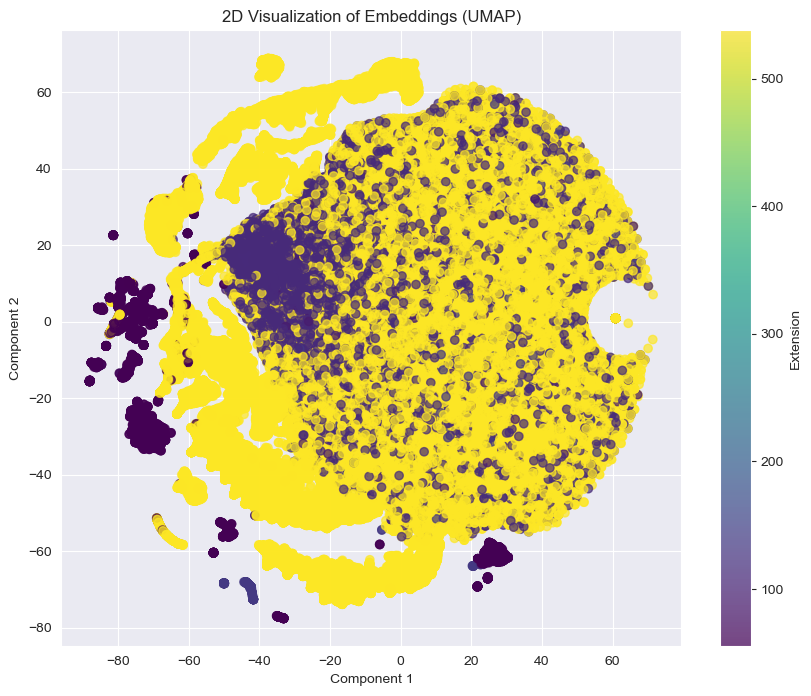

In [20]:
plt.figure(figsize=(10, 8))
scatter = plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1],
                      c=ext_values,  # Или другой лейбл, если ext — числовой/категориальный
                      cmap='viridis', alpha=0.7)
plt.colorbar(scatter, label='Extension')
plt.title('2D Visualization of Embeddings (UMAP)')
plt.xlabel('Component 1')
plt.ylabel('Component 2')

In [22]:
df['ext']

0         [538]
1         [538]
2         [538]
3         [538]
4          [55]
          ...  
178855    [538]
178856    [538]
178857    [538]
178858    [113]
178859     [55]
Name: ext, Length: 178860, dtype: object